# Customer Churn Prediction using Machine Learning



# Project Overview

In the highly competitive telecommunications industry, retaining existing customers is more cost-effective than acquiring new ones. Customer churn  the rate at which customers discontinue their services directly impacts company revenue and growth.

This project uses Machine Learning techniques to analyse customer behaviour patterns and predict whether a customer is likely to churn. The objective is to help businesses identify high-risk customers early and implement proactive retention strategies.



# Problem Statement

Telecom companies experience customer churn due to several factors such as:

- High service charges
- Poor customer satisfaction
- Better offers from competitors
- Lack of customer engagement

Traditional retention strategies are often reactive and inefficient. Therefore, predicting churn in advance can significantly improve customer retention and business profitability.



# Proposed Solution

This project develops a complete machine learning pipeline for customer churn prediction using historical telecom customer data.

The workflow includes:

- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training and Evaluation
- Business Insight Generation

Two machine learning models were implemented:

1. Logistic Regression
2. Random Forest Classifier

The performance of these models was evaluated using:

- Accuracy Score
- Classification Report
- ROC-AUC Score
- Confusion Matrix


# Business Impact

This solution can help telecom companies:

- Reduce customer attrition
- Improve retention strategies
- Increase customer lifetime value
- Optimise marketing campaigns
- Identify high-risk customer segments

By leveraging predictive analytics, businesses can make more informed and data-driven decisions.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [22]:
# VISUAL SETTINGS

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Dataset Information

Dataset Source:
Kaggle Telco Customer Churn Dataset

Total Rows: 7043       
Total Columns: 21

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis (EDA)

EDA is performed to understand customer behaviour patterns, identify trends, detect anomalies, and uncover relationships between variables.

/tmp/ipykernel_5896/730608292.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


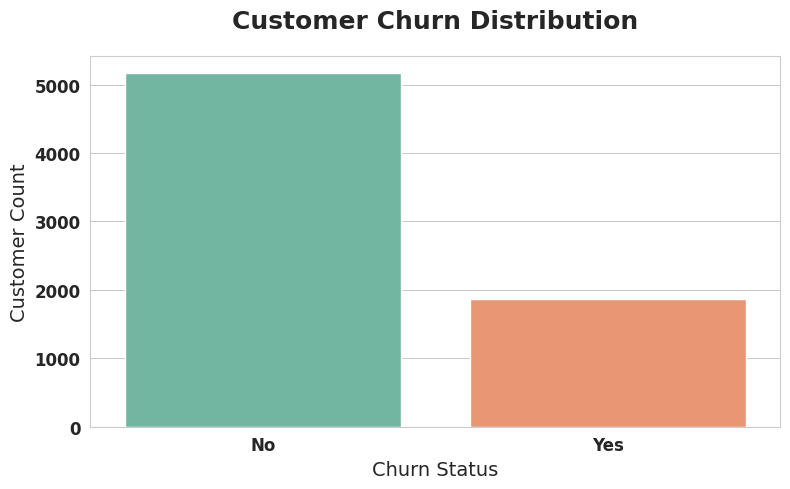

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Churn',
    data=df,
    palette='Set2'
)

plt.title("Customer Churn Distribution", pad=20)
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.show()

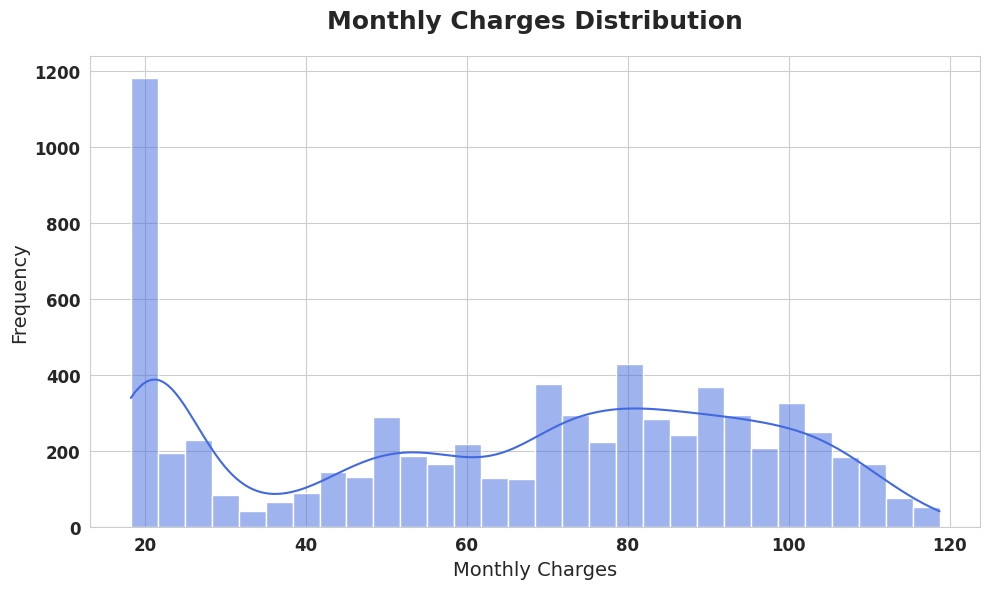

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['MonthlyCharges'],
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title("Monthly Charges Distribution", pad=20)
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
# Drop rows with NaN values (introduced by 'coerce' in TotalCharges conversion)
df.dropna(inplace=True)

# Encode categorical features in X
X = pd.get_dummies(df.drop(['Churn', 'customerID'], axis=1), drop_first=True)

# Encode the target variable y
le = LabelEncoder()
y = le.fit_transform(df['Churn'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# FEATURE SCALING

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("===== Logistic Regression =====")

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_log))

===== Logistic Regression =====
Accuracy Score:
0.7874911158493249

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


ROC-AUC Score:
0.7009061919232185


# Machine Learning Model Building

Two machine learning models were trained and evaluated:
- Logistic Regression
- Random Forest Classifier

In [16]:
# RANDOM FOREST CLASSIFIER

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("===== Random Forest =====")

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_rf))

===== Random Forest =====
Accuracy Score:
0.7910447761194029

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407


ROC-AUC Score:
0.6930918719683596


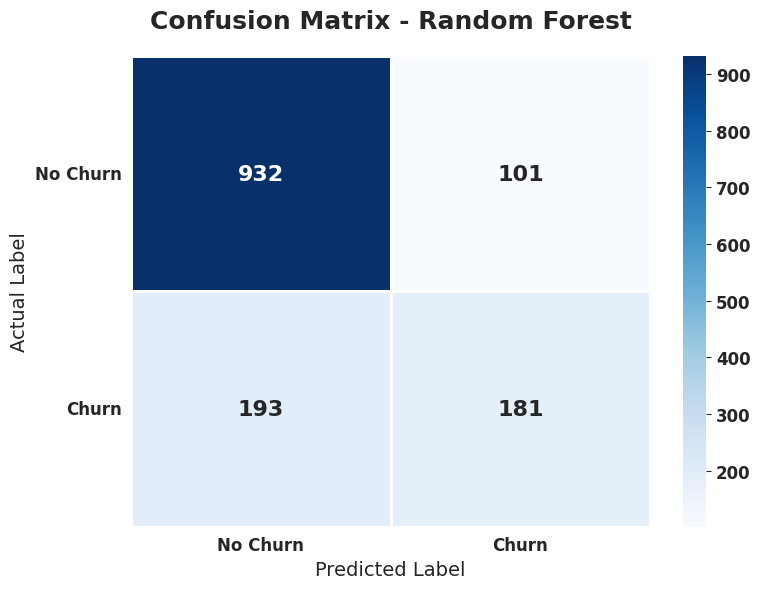

In [25]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=2,
    linecolor='white',
    cbar=True,
    annot_kws={"size":16, "weight":"bold"}
)

plt.title("Confusion Matrix - Random Forest", pad=20)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0.5,1.5], ['No Churn', 'Churn'])
plt.yticks([0.5,1.5], ['No Churn', 'Churn'], rotation=0)

plt.tight_layout()

plt.show()

/tmp/ipykernel_5896/170597214.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


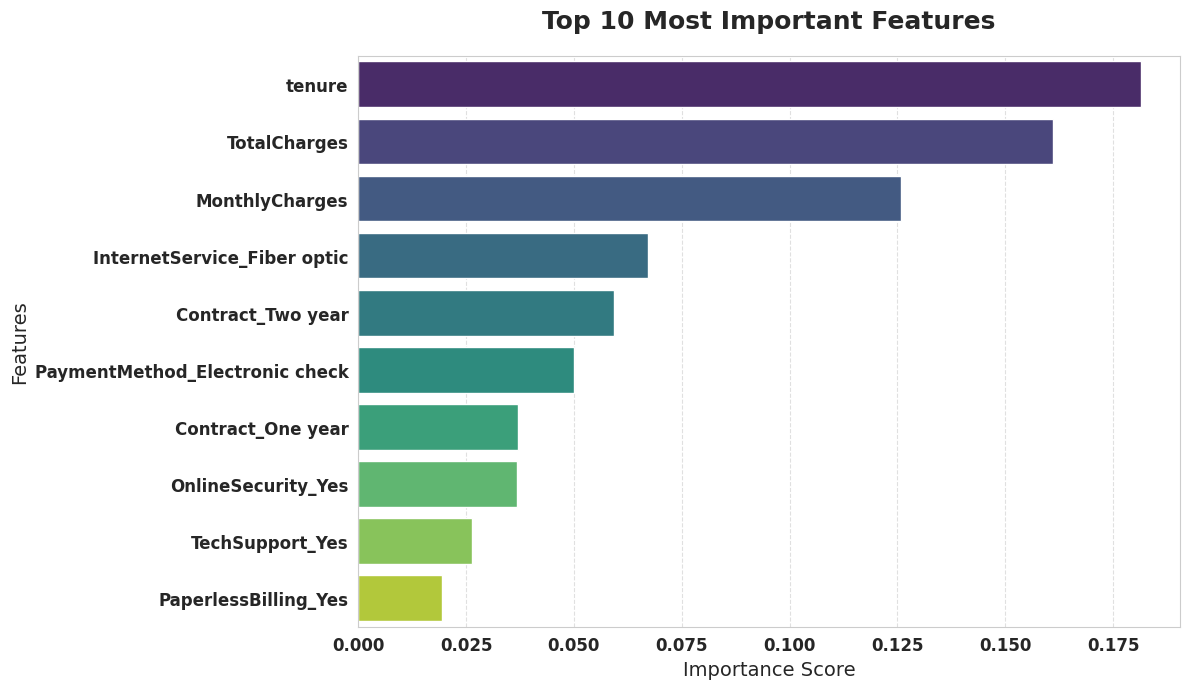

In [26]:
# FEATURE IMPORTANCE VISUALIZATION

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top_features = feature_importance.head(10)

plt.figure(figsize=(12,7))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
    palette='viridis'
)

plt.title("Top 10 Most Important Features", pad=20)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

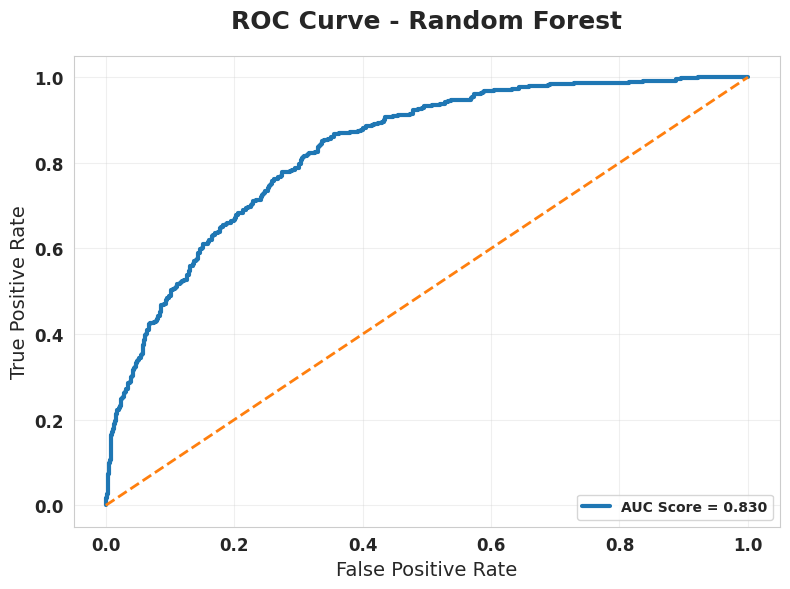

In [27]:
# ROC CURVE

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'AUC Score = {auc_score:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2
)

plt.title("ROC Curve - Random Forest", pad=20)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

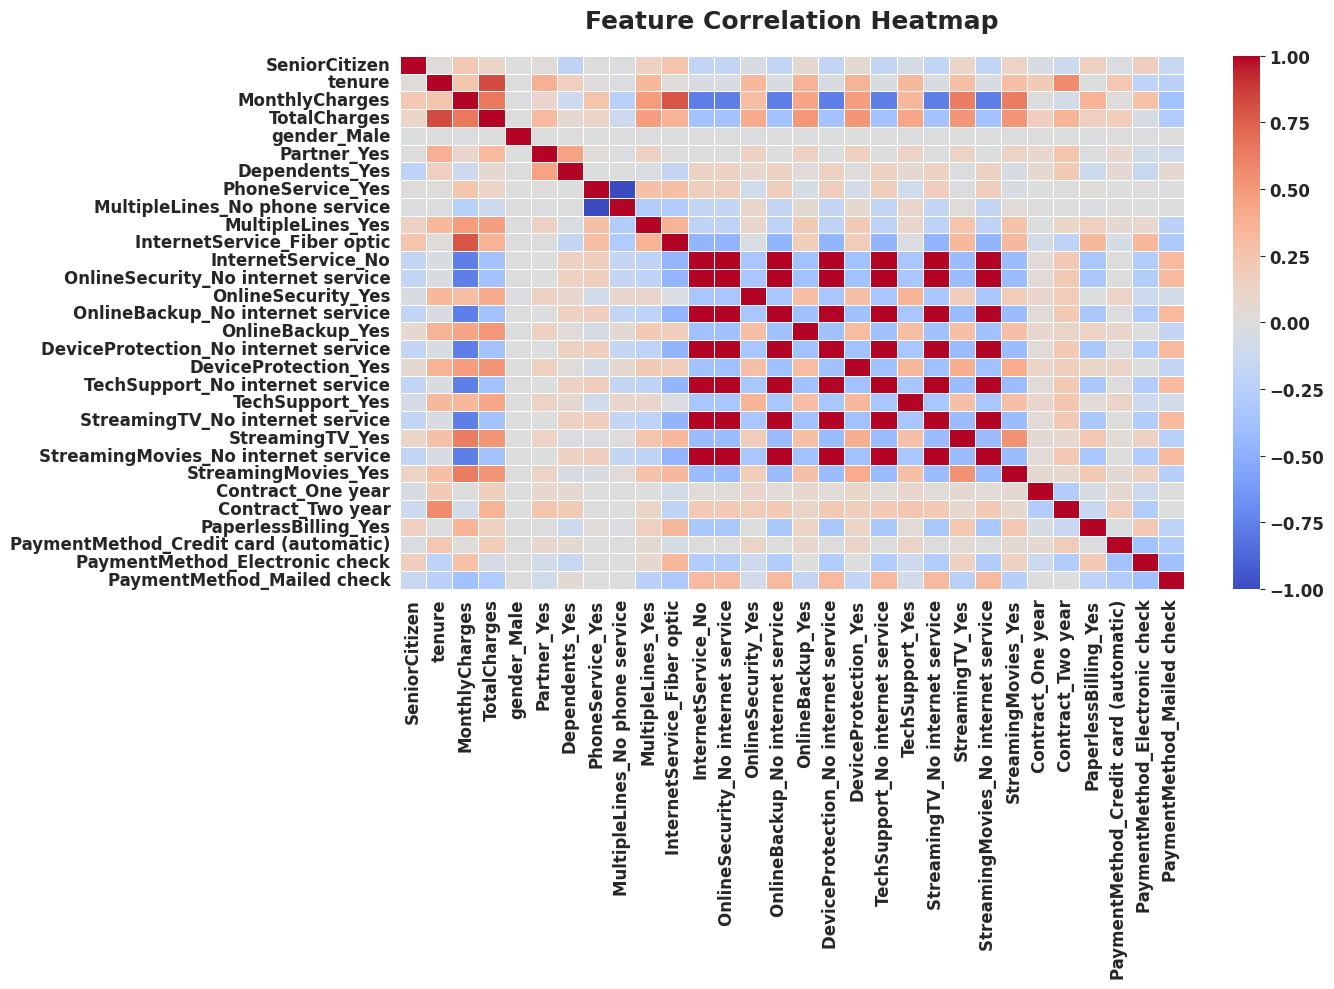

In [30]:
# CORRELATION HEATMAP

plt.figure(figsize=(14,10))

correlation = X.corr()

sns.heatmap(
    correlation,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", pad=20)

plt.tight_layout()

plt.show()

# Conclusion

The project successfully analysed customer churn behaviour using exploratory data analysis and machine learning techniques.

Key findings:
- Customers with month-to-month contracts are more likely to churn.
- Higher monthly charges increase churn probability.
- Long-term customers are less likely to leave.

Among the tested models, Random Forest performed better than Logistic Regression and achieved strong predictive performance.

This project demonstrates practical skills in:
- Data cleaning
- Feature engineering
- Exploratory Data Analysis
- Machine Learning
- Model evaluation
- Business insight generation